<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_SegmentasiCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

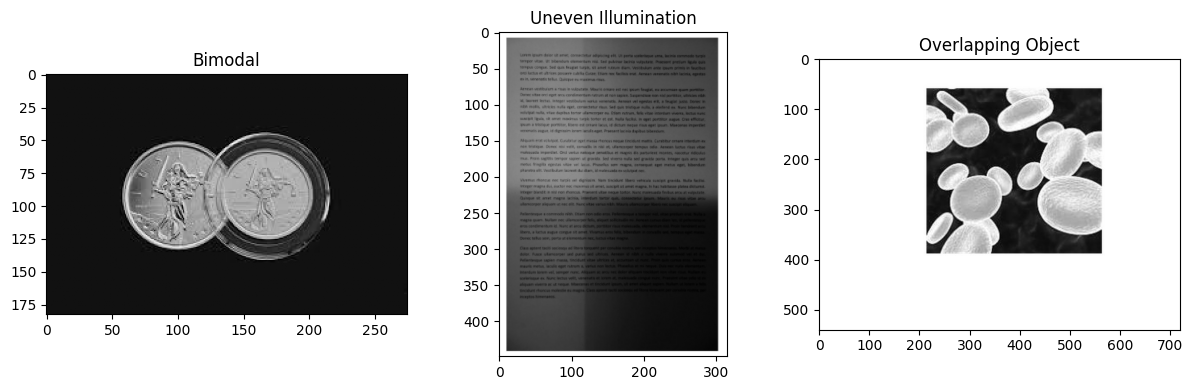

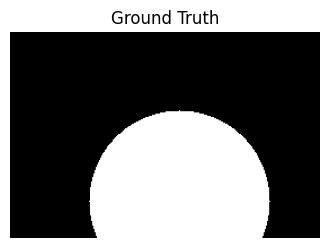

Waktu Global Threshold : 0.0004s
Threshold Otsu         : 85.0
Waktu Otsu             : 0.0004s
Waktu Adaptive Mean    : 0.0008s
Waktu Adaptive Gaussian: 0.0012s


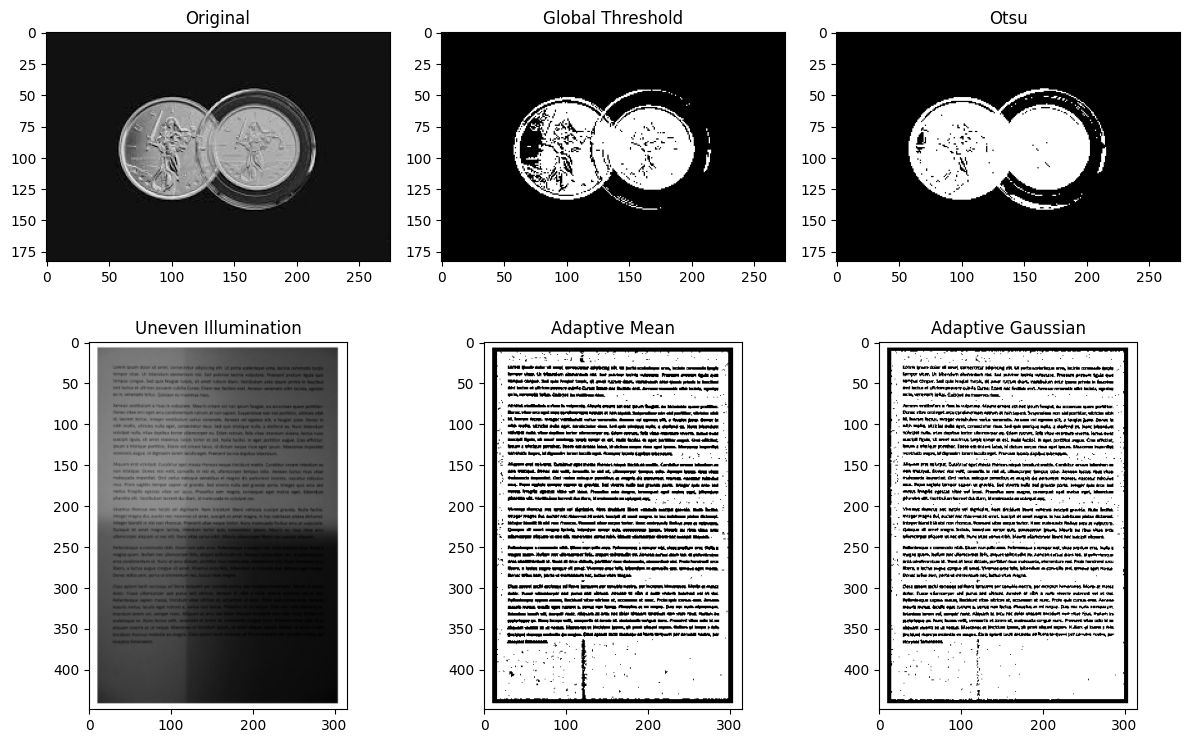

Waktu Sobel  : 0.0033s
Waktu Prewitt: 0.0008s
Waktu Canny  : 0.0014s


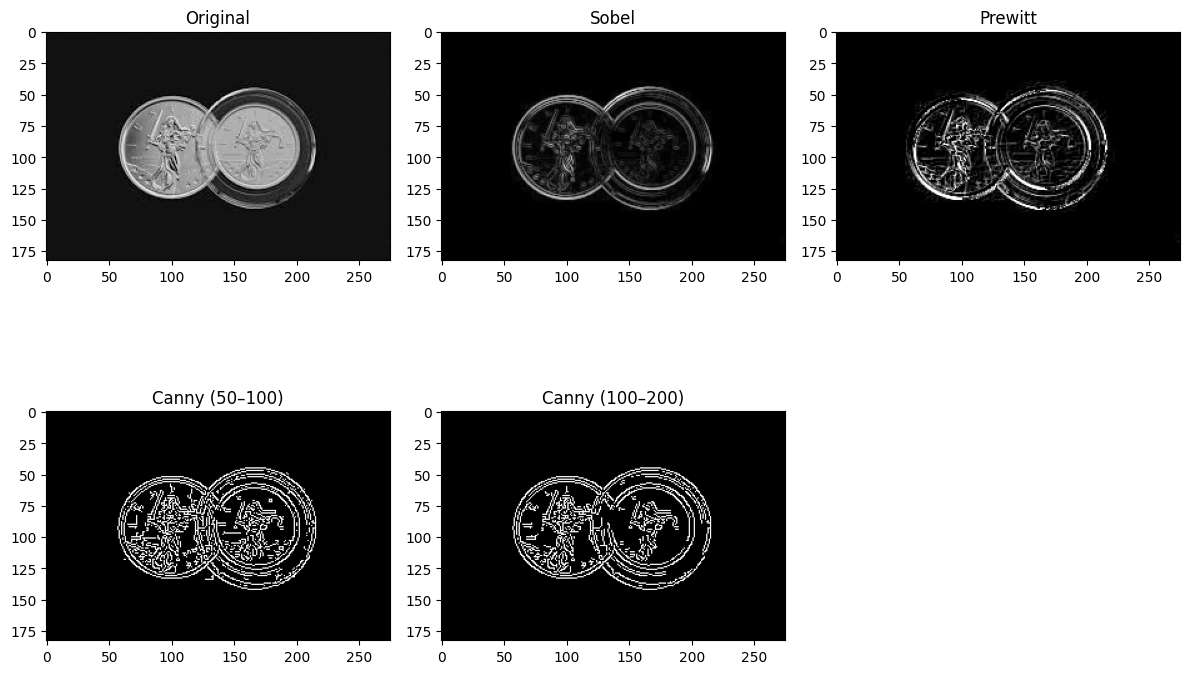

Jumlah Objek (Connected Components): 31


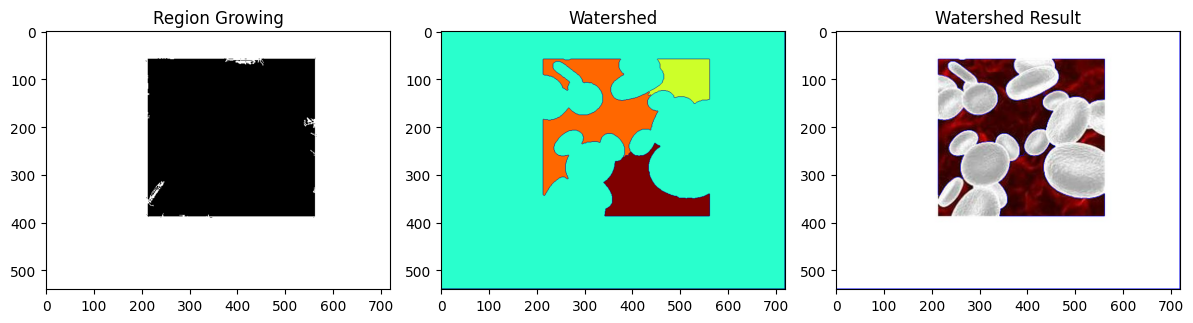

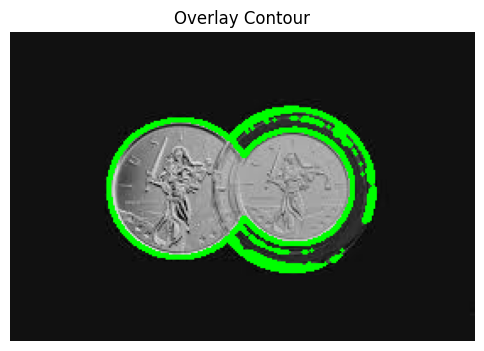

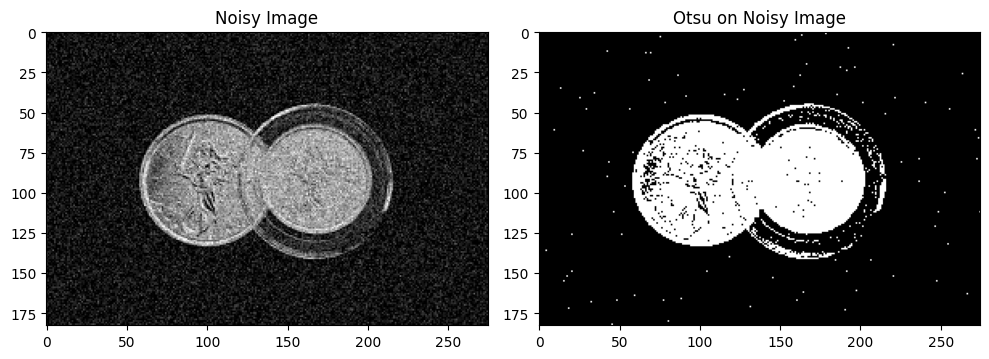


===== METRIK EVALUASI SEGMENTASI =====
                      IoU    Dice  Accuracy  Precision  Recall  F1 Score
Metode                                                                  
Global Threshold   0.2818  0.4397    0.7492     0.6659  0.3282    0.4397
Otsu               0.3033  0.4655    0.7425     0.6160  0.3740    0.4655
Adaptive Mean      0.2856  0.4444    0.4189     0.3132  0.7645    0.4444
Adaptive Gaussian  0.2905  0.4502    0.4041     0.3128  0.8028    0.4502


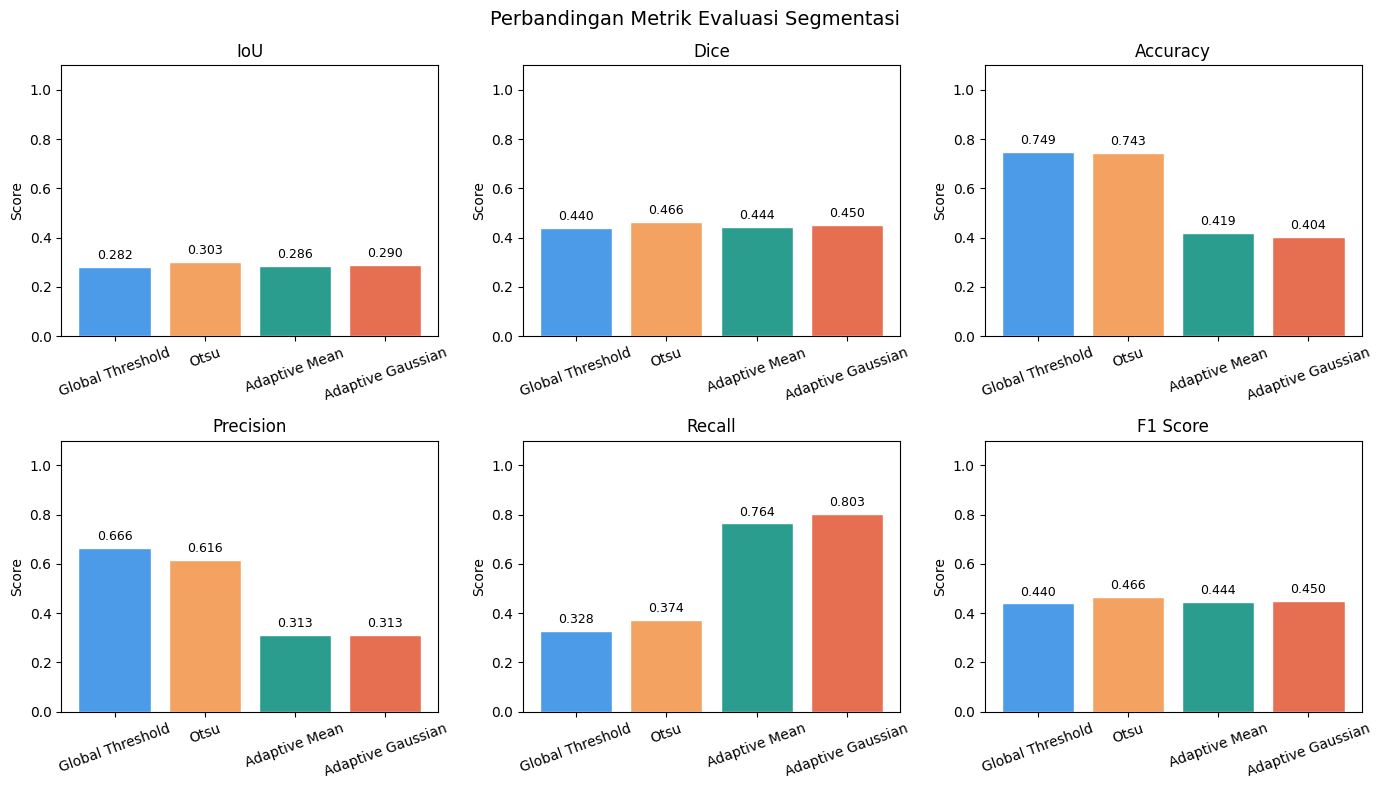

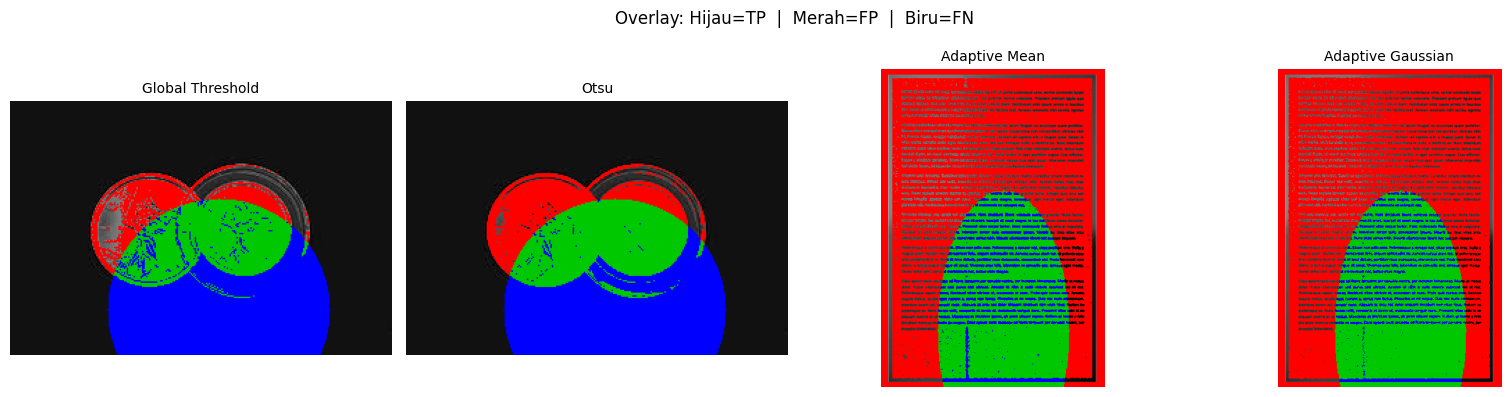

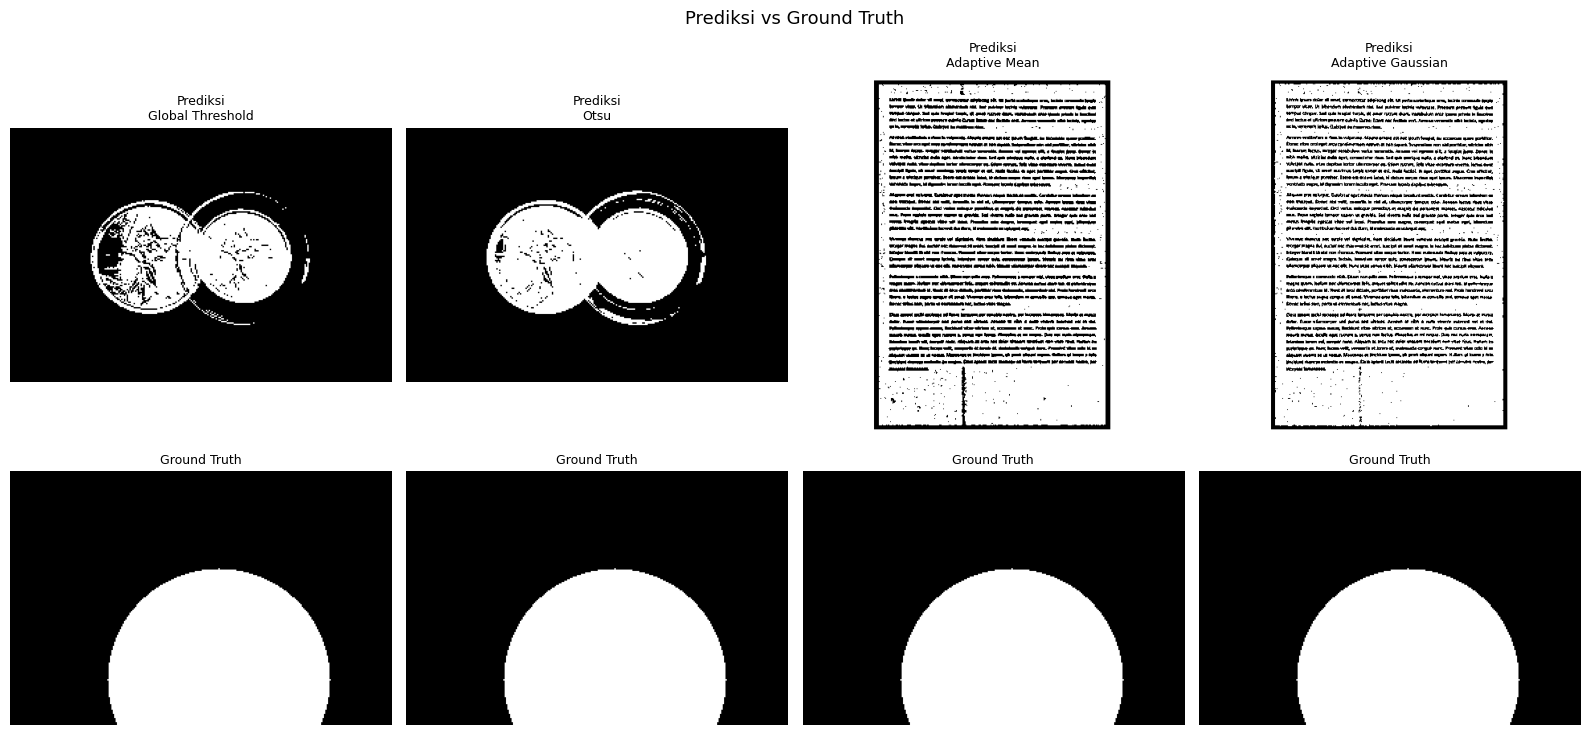


===== WAKTU KOMPUTASI (rata-rata 50x) =====
  Global Threshold      : 0.009 ms
  Otsu                  : 0.065 ms
  Adaptive Mean         : 0.673 ms
  Adaptive Gaussian     : 0.959 ms
  Sobel                 : 0.612 ms
  Prewitt               : 0.211 ms
  Canny (50-100)        : 0.506 ms
  Canny (100-200)       : 0.438 ms


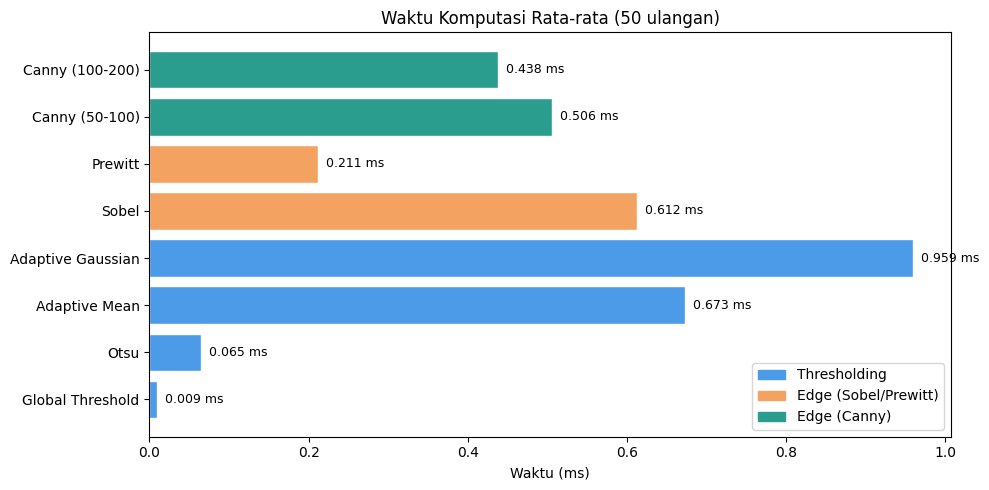

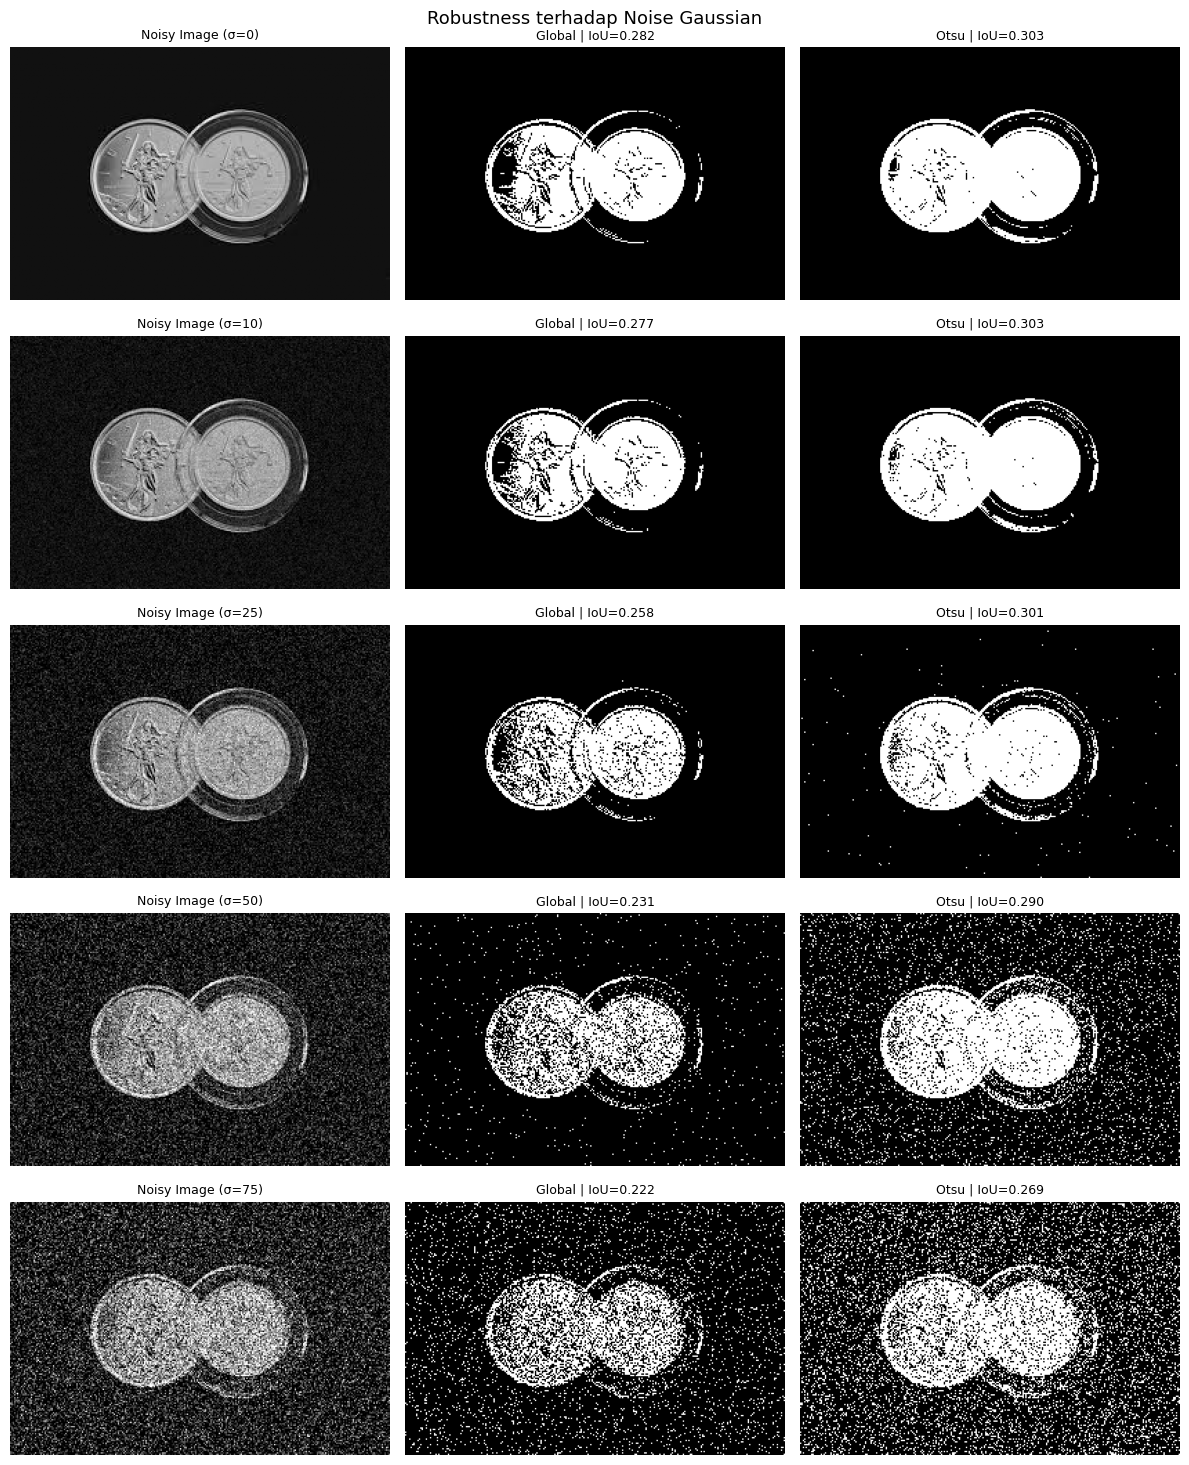

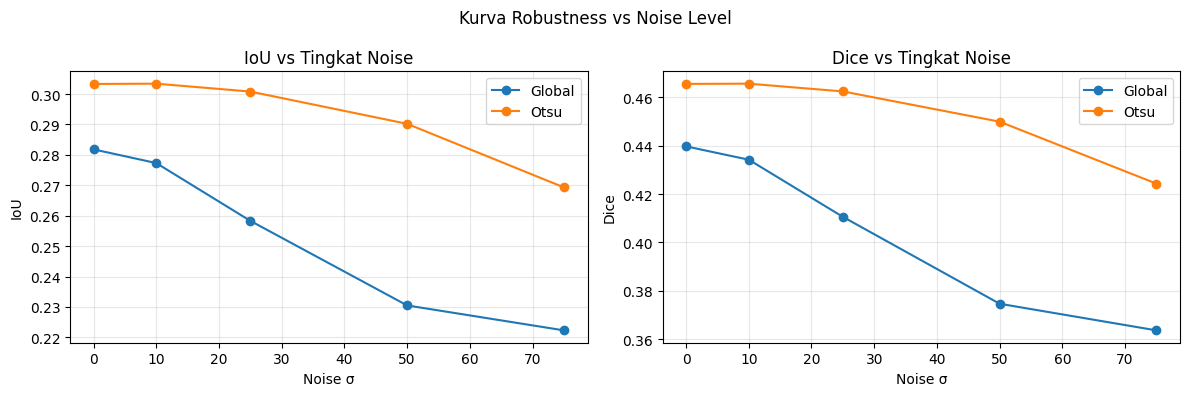

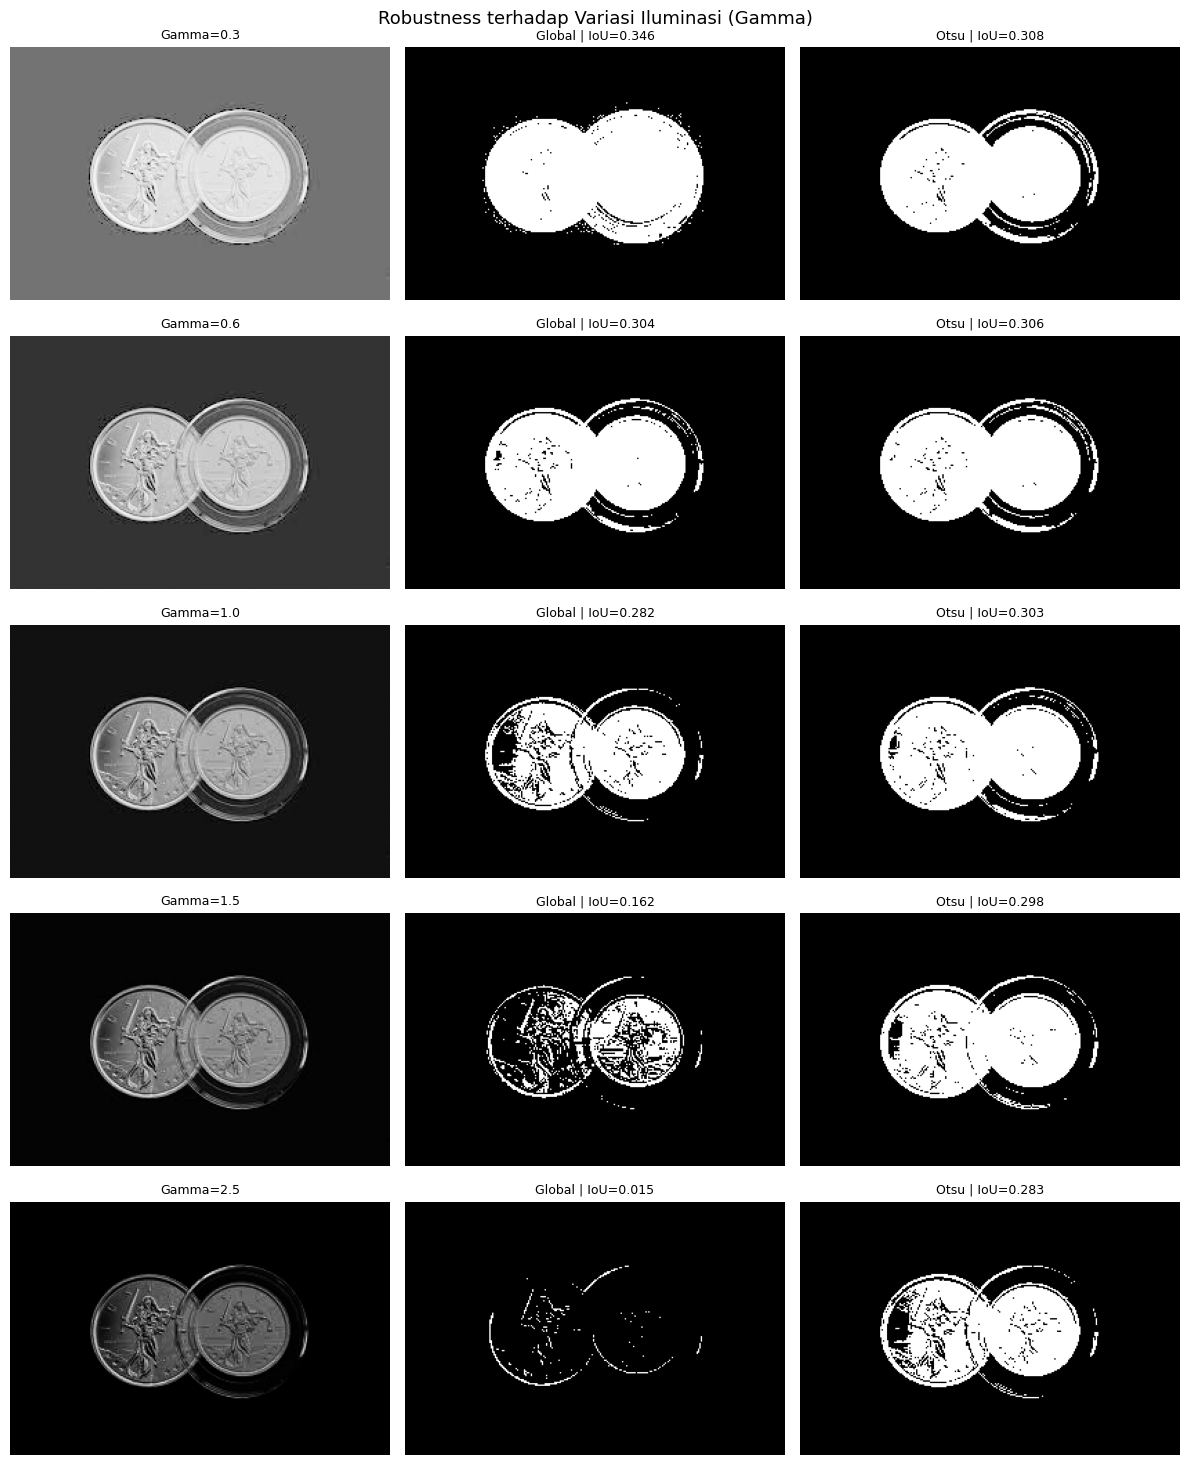

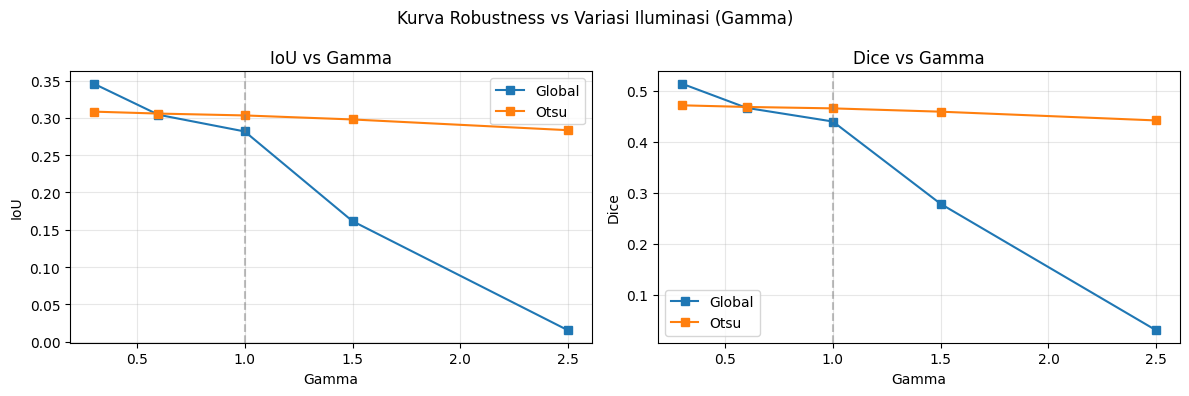


===== RINGKASAN EVALUASI KOMPREHENSIF =====
                      IoU    Dice  Accuracy  Precision  Recall  F1 Score
Metode                                                                  
Global Threshold   0.2818  0.4397    0.7492     0.6659  0.3282    0.4397
Otsu               0.3033  0.4655    0.7425     0.6160  0.3740    0.4655
Adaptive Mean      0.2856  0.4444    0.4189     0.3132  0.7645    0.4444
Adaptive Gaussian  0.2905  0.4502    0.4041     0.3128  0.8028    0.4502

Metode terbaik (IoU tertinggi): Otsu
Metode terbaik (Dice tertinggi): Otsu
Metode terbaik (F1 tertinggi) : Otsu

Metode tercepat: Global Threshold
Metode terlambat: Adaptive Gaussian


In [13]:
# ============================================================
# PRAKTIKUM 9 - SEGMENTASI CITRA DAN EDGE DETECTION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# LOAD CITRA
# ============================================================

img_bimodal = cv2.imread('bimodal.jpeg', 0)
img_uneven  = cv2.imread('uneven.png',  0)
img_overlap = cv2.imread('overlap.jpg', 0)

groundtruth = np.zeros_like(img_bimodal)

cv2.circle(
    groundtruth,
    (150,150),
    80,
    255,
    -1
)
# ============================================================
# TAMPILKAN CITRA ASLI
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, img, title in zip(
    axes,
    [img_bimodal, img_uneven, img_overlap],
    ['Bimodal', 'Uneven Illumination', 'Overlapping Object']
):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Tampilkan Ground Truth
plt.figure(figsize=(4,4))
plt.imshow(groundtruth, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')
plt.show()



# ============================================================
# THRESHOLDING
# ============================================================

# --- Global Threshold ---
t0 = time.time()
_, global_thresh = cv2.threshold(img_bimodal, 127, 255, cv2.THRESH_BINARY)
print(f"Waktu Global Threshold : {time.time() - t0:.4f}s")

# --- Otsu Threshold ---
t0 = time.time()
otsu_T, otsu_thresh = cv2.threshold(img_bimodal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Threshold Otsu         : {otsu_T}")
print(f"Waktu Otsu             : {time.time() - t0:.4f}s")

# --- Adaptive Mean ---
t0 = time.time()
adaptive_mean = cv2.adaptiveThreshold(
    img_uneven, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize=11, C=2
)
print(f"Waktu Adaptive Mean    : {time.time() - t0:.4f}s")

# --- Adaptive Gaussian ---
t0 = time.time()
adaptive_gaussian = cv2.adaptiveThreshold(
    img_uneven, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11, C=2
)
print(f"Waktu Adaptive Gaussian: {time.time() - t0:.4f}s")


# --- Visualisasi Thresholding ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

pairs = [
    (img_bimodal,      'Original'),
    (global_thresh,    'Global Threshold'),
    (otsu_thresh,      'Otsu'),
    (img_uneven,       'Uneven Illumination'),
    (adaptive_mean,    'Adaptive Mean'),
    (adaptive_gaussian,'Adaptive Gaussian'),
]

for ax, (img, title) in zip(axes.flat, pairs):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

plt.tight_layout()
plt.show()


# ============================================================
# EDGE DETECTION
# ============================================================

# --- Sobel ---
t0 = time.time()
sobel_x = cv2.Sobel(img_bimodal, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_bimodal, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
print(f"Waktu Sobel  : {time.time() - t0:.4f}s")

# --- Prewitt ---
t0 = time.time()
kernel_x = np.array([[ 1, 0, -1],
                      [ 1, 0, -1],
                      [ 1, 0, -1]])
kernel_y = np.array([[ 1,  1,  1],
                      [ 0,  0,  0],
                      [-1, -1, -1]])
prewitt_x = cv2.filter2D(img_bimodal, -1, kernel_x)
prewitt_y = cv2.filter2D(img_bimodal, -1, kernel_y)
prewitt   = prewitt_x + prewitt_y
print(f"Waktu Prewitt: {time.time() - t0:.4f}s")

# --- Canny ---
t0 = time.time()
canny_low  = cv2.Canny(img_bimodal,  50, 100)
canny_high = cv2.Canny(img_bimodal, 100, 200)
print(f"Waktu Canny  : {time.time() - t0:.4f}s")


# --- Visualisasi Edge Detection ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

edge_pairs = [
    (img_bimodal, 'Original'),
    (sobel_mag,   'Sobel'),
    (prewitt,     'Prewitt'),
    (canny_low,   'Canny (50–100)'),
    (canny_high,  'Canny (100–200)'),
]

for ax, (img, title) in zip(axes.flat, edge_pairs):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

axes.flat[-1].set_visible(False)  # sembunyikan subplot kosong
plt.tight_layout()
plt.show()


# ============================================================
# SEGMENTASI BERBASIS REGION
# ============================================================

# --- Region Growing ---
img    = img_overlap.copy()
visited = np.zeros_like(img)
region  = np.zeros_like(img)

SEED       = (100, 100)
THRESHOLD  = 10
seed_val   = int(img[SEED[1], SEED[0]])
stack      = [SEED]

while stack:
    x, y = stack.pop()
    if visited[y, x]:
        continue
    visited[y, x] = 1
    if abs(int(img[y, x]) - seed_val) < THRESHOLD:
        region[y, x] = 255
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < img.shape[1] and 0 <= ny < img.shape[0]:
                    stack.append((nx, ny))


# --- Watershed ---
img_color = cv2.imread('overlap.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel  = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg  = np.uint8(sure_fg)
unknown  = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(img_color, markers)
img_color[markers == -1] = [255, 0, 0]


# --- Connected Components ---
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    otsu_thresh, connectivity=8
)
print(f"Jumlah Objek (Connected Components): {num_labels - 1}")


# --- Visualisasi Region-Based ---
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(region, cmap='gray')
axes[0].set_title('Region Growing')

axes[1].imshow(markers, cmap='jet')
axes[1].set_title('Watershed')

axes[2].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Watershed Result')

plt.tight_layout()
plt.show()


# ============================================================
# OVERLAY CONTOUR
# ============================================================

contours, _ = cv2.findContours(otsu_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = cv2.cvtColor(img_bimodal, cv2.COLOR_GRAY2BGR)
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title('Overlay Contour')
plt.axis('off')
plt.show()


# ============================================================
# UJI ROBUSTNESS TERHADAP NOISE
# ============================================================

noise        = np.random.normal(0, 25, img_bimodal.shape)
noisy_image  = np.clip(img_bimodal + noise, 0, 255).astype(np.uint8)

_, noisy_otsu = cv2.threshold(noisy_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(noisy_image, cmap='gray');  axes[0].set_title('Noisy Image')
axes[1].imshow(noisy_otsu,  cmap='gray');  axes[1].set_title('Otsu on Noisy Image')
plt.tight_layout()
plt.show()

# ============================================================
# EVALUASI KOMPREHENSIF
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


# ============================================================
# FUNGSI BANTU METRIK
# ============================================================

def compute_metrics(gt_img, pred_img, label=""):
    """Hitung IoU, Dice, Accuracy, Precision, Recall dari dua citra biner."""
    gt   = (gt_img.flatten() > 0).astype(int)
    pred = (pred_img.flatten() > 0).astype(int)

    intersection = np.logical_and(gt, pred).sum()
    union        = np.logical_or(gt, pred).sum()

    iou       = intersection / union if union > 0 else 0.0
    dice      = (2 * intersection) / (gt.sum() + pred.sum()) if (gt.sum() + pred.sum()) > 0 else 0.0
    accuracy  = accuracy_score(gt, pred)
    precision = precision_score(gt, pred, zero_division=0)
    recall    = recall_score(gt, pred, zero_division=0)
    f1        = f1_score(gt, pred, zero_division=0)

    return {
        "Metode"    : label,
        "IoU"       : round(iou, 4),
        "Dice"      : round(dice, 4),
        "Accuracy"  : round(accuracy, 4),
        "Precision" : round(precision, 4),
        "Recall"    : round(recall, 4),
        "F1 Score"  : round(f1, 4),
    }


# ============================================================
# 1. METRIK: IoU, DICE, ACCURACY, PRECISION, RECALL
#    Evaluasi semua metode thresholding terhadap ground truth
# ============================================================
gt_bimodal = groundtruth.copy()

gt_uneven = cv2.resize(
    groundtruth,
    (img_uneven.shape[1], img_uneven.shape[0])
)

results = []
results.append(compute_metrics(gt_bimodal, global_thresh, "Global Threshold"))
results.append(compute_metrics(gt_bimodal, otsu_thresh,   "Otsu"))
results.append(compute_metrics(gt_uneven, adaptive_mean, "Adaptive Mean"))
results.append(compute_metrics(gt_uneven, adaptive_gaussian, "Adaptive Gaussian"))

df_metrics = pd.DataFrame(results).set_index("Metode")

print("\n===== METRIK EVALUASI SEGMENTASI =====")
print(df_metrics.to_string())

# --- Visualisasi bar chart metrik ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Perbandingan Metrik Evaluasi Segmentasi', fontsize=14)

metric_cols = ["IoU", "Dice", "Accuracy", "Precision", "Recall", "F1 Score"]
colors = ['#4C9BE8', '#F4A261', '#2A9D8F', '#E76F51']

for ax, col in zip(axes.flat, metric_cols):
    bars = ax.bar(df_metrics.index, df_metrics[col], color=colors, edgecolor='white')
    ax.set_title(col)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, df_metrics[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()


# ============================================================
# 2. VISUAL: OVERLAY CONTOUR + PERBANDINGAN GROUND TRUTH
# ============================================================

def overlay_with_gt(original, pred, gt, title=""):
    """Buat overlay: hijau = TP, merah = FP, biru = FN."""
    vis = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    pred_bin = (pred > 0)
    gt_bin   = (gt > 0)

    tp = pred_bin & gt_bin
    fp = pred_bin & ~gt_bin
    fn = ~pred_bin & gt_bin

    vis[tp] = [0, 200, 0]    # TP = hijau
    vis[fp] = [0, 0, 255]    # FP = merah
    vis[fn] = [255, 0, 0]    # FN = biru
    return vis, title

# Ground truth untuk bimodal
gt_bimodal = groundtruth.copy()

# Ground truth disesuaikan dengan ukuran uneven
gt_uneven = cv2.resize(
    groundtruth,
    (img_uneven.shape[1], img_uneven.shape[0])
)


overlays = [
    overlay_with_gt(img_bimodal, global_thresh,    gt_bimodal, "Global Threshold"),
    overlay_with_gt(img_bimodal, otsu_thresh,       gt_bimodal, "Otsu"),
    overlay_with_gt(img_uneven, adaptive_mean,     gt_uneven, "Adaptive Mean"),
    overlay_with_gt(img_uneven, adaptive_gaussian, gt_uneven, "Adaptive Gaussian"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    'Overlay: Hijau=TP  |  Merah=FP  |  Biru=FN',
    fontsize=12
)

for ax, (vis, title) in zip(axes, overlays):
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


# --- Side-by-side: prediksi vs ground truth ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Prediksi vs Ground Truth', fontsize=13)

methods = [
    (global_thresh,    "Global Threshold"),
    (otsu_thresh,      "Otsu"),
    (adaptive_mean,    "Adaptive Mean"),
    (adaptive_gaussian,"Adaptive Gaussian"),
]

for col, (pred, name) in enumerate(methods):
    axes[0, col].imshow(pred, cmap='gray')
    axes[0, col].set_title(f'Prediksi\n{name}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(groundtruth, cmap='gray')
    axes[1, col].set_title('Ground Truth', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# 3. WAKTU KOMPUTASI TIAP METODE
# ============================================================

REPEAT = 50  # jumlah pengulangan untuk estimasi waktu rata-rata

timing_results = {}

# Thresholding
runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.threshold(img_bimodal, 127, 255, cv2.THRESH_BINARY)
    runs.append(time.time() - t0)
timing_results["Global Threshold"] = np.mean(runs)

runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.threshold(img_bimodal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    runs.append(time.time() - t0)
timing_results["Otsu"] = np.mean(runs)

runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.adaptiveThreshold(img_uneven, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                          cv2.THRESH_BINARY, 11, 2)
    runs.append(time.time() - t0)
timing_results["Adaptive Mean"] = np.mean(runs)

runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.adaptiveThreshold(img_uneven, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                          cv2.THRESH_BINARY, 11, 2)
    runs.append(time.time() - t0)
timing_results["Adaptive Gaussian"] = np.mean(runs)

# Edge Detection
runs = []
for _ in range(REPEAT):
    t0 = time.time()
    sx = cv2.Sobel(img_bimodal, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img_bimodal, cv2.CV_64F, 0, 1, ksize=3)
    np.sqrt(sx**2 + sy**2)
    runs.append(time.time() - t0)
timing_results["Sobel"] = np.mean(runs)

runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.filter2D(img_bimodal, -1, kernel_x)
    cv2.filter2D(img_bimodal, -1, kernel_y)
    runs.append(time.time() - t0)
timing_results["Prewitt"] = np.mean(runs)

runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.Canny(img_bimodal, 50, 100)
    runs.append(time.time() - t0)
timing_results["Canny (50-100)"] = np.mean(runs)

runs = []
for _ in range(REPEAT):
    t0 = time.time()
    cv2.Canny(img_bimodal, 100, 200)
    runs.append(time.time() - t0)
timing_results["Canny (100-200)"] = np.mean(runs)

# Print tabel waktu
print(f"\n===== WAKTU KOMPUTASI (rata-rata {REPEAT}x) =====")
for name, t in timing_results.items():
    print(f"  {name:<22}: {t*1000:.3f} ms")

# Visualisasi waktu komputasi
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(timing_results.keys())
times  = [v * 1000 for v in timing_results.values()]
colors_bar = [
    '#4C9BE8','#4C9BE8','#4C9BE8','#4C9BE8',  # thresholding
    '#F4A261','#F4A261',                         # edge
    '#2A9D8F','#2A9D8F',                         # edge canny
]

bars = ax.barh(names, times, color=colors_bar, edgecolor='white')
ax.set_xlabel('Waktu (ms)')
ax.set_title(f'Waktu Komputasi Rata-rata ({REPEAT} ulangan)')

for bar, val in zip(bars, times):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f} ms",
        va='center', fontsize=9
    )

# Legenda kategori
from matplotlib.patches import Patch
legend = [
    Patch(color='#4C9BE8', label='Thresholding'),
    Patch(color='#F4A261', label='Edge (Sobel/Prewitt)'),
    Patch(color='#2A9D8F', label='Edge (Canny)'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()


# ============================================================
# 4. ROBUSTNESS TERHADAP NOISE DAN VARIASI ILUMINASI
# ============================================================

# --- 4a. Noise Gaussian dengan berbagai sigma ---
sigma_levels = [0, 10, 25, 50, 75]

fig, axes = plt.subplots(
    len(sigma_levels), 3,
    figsize=(12, len(sigma_levels) * 3)
)
fig.suptitle('Robustness terhadap Noise Gaussian', fontsize=13)

noise_metrics = []

for row, sigma in enumerate(sigma_levels):
    if sigma == 0:
        noisy = img_bimodal.copy()
    else:
        noise = np.random.normal(0, sigma, img_bimodal.shape)
        noisy = np.clip(img_bimodal + noise, 0, 255).astype(np.uint8)

    _, noisy_global = cv2.threshold(noisy, 127, 255, cv2.THRESH_BINARY)
    _, noisy_otsu   = cv2.threshold(noisy, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    m_global = compute_metrics(groundtruth, noisy_global, f"Global σ={sigma}")
    m_otsu   = compute_metrics(groundtruth, noisy_otsu,   f"Otsu σ={sigma}")
    noise_metrics.append({"sigma": sigma, "metode": "Global", "IoU": m_global["IoU"], "Dice": m_global["Dice"]})
    noise_metrics.append({"sigma": sigma, "metode": "Otsu",   "IoU": m_otsu["IoU"],   "Dice": m_otsu["Dice"]})

    axes[row, 0].imshow(noisy, cmap='gray')
    axes[row, 0].set_title(f'Noisy Image (σ={sigma})', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(noisy_global, cmap='gray')
    axes[row, 1].set_title(f'Global | IoU={m_global["IoU"]:.3f}', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(noisy_otsu, cmap='gray')
    axes[row, 2].set_title(f'Otsu | IoU={m_otsu["IoU"]:.3f}', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


# --- Kurva IoU vs Noise Level ---
df_noise = pd.DataFrame(noise_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Kurva Robustness vs Noise Level', fontsize=12)

for ax, metric in zip(axes, ["IoU", "Dice"]):
    for metode, grp in df_noise.groupby("metode"):
        ax.plot(grp["sigma"], grp[metric], marker='o', label=metode)
    ax.set_xlabel('Noise σ')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Tingkat Noise')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# --- 4b. Variasi Iluminasi (gamma correction) ---
gamma_levels = [0.3, 0.6, 1.0, 1.5, 2.5]

fig, axes = plt.subplots(
    len(gamma_levels), 3,
    figsize=(12, len(gamma_levels) * 3)
)
fig.suptitle('Robustness terhadap Variasi Iluminasi (Gamma)', fontsize=13)

illum_metrics = []

for row, gamma in enumerate(gamma_levels):
    lut = np.array([
        np.clip((i / 255.0) ** gamma * 255, 0, 255)
        for i in range(256)
    ], dtype=np.uint8)

    adjusted = cv2.LUT(img_bimodal, lut)

    _, adj_global = cv2.threshold(adjusted, 127, 255, cv2.THRESH_BINARY)
    _, adj_otsu   = cv2.threshold(adjusted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    m_global = compute_metrics(groundtruth, adj_global, f"Global γ={gamma}")
    m_otsu   = compute_metrics(groundtruth, adj_otsu,   f"Otsu γ={gamma}")
    illum_metrics.append({"gamma": gamma, "metode": "Global", "IoU": m_global["IoU"], "Dice": m_global["Dice"]})
    illum_metrics.append({"gamma": gamma, "metode": "Otsu",   "IoU": m_otsu["IoU"],   "Dice": m_otsu["Dice"]})

    axes[row, 0].imshow(adjusted, cmap='gray')
    axes[row, 0].set_title(f'Gamma={gamma}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(adj_global, cmap='gray')
    axes[row, 1].set_title(f'Global | IoU={m_global["IoU"]:.3f}', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(adj_otsu, cmap='gray')
    axes[row, 2].set_title(f'Otsu | IoU={m_otsu["IoU"]:.3f}', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


# --- Kurva IoU vs Gamma ---
df_illum = pd.DataFrame(illum_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Kurva Robustness vs Variasi Iluminasi (Gamma)', fontsize=12)

for ax, metric in zip(axes, ["IoU", "Dice"]):
    for metode, grp in df_illum.groupby("metode"):
        ax.plot(grp["gamma"], grp[metric], marker='s', label=metode)
    ax.set_xlabel('Gamma')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Gamma')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='γ=1 (normal)')

plt.tight_layout()
plt.show()


# ============================================================
# RINGKASAN AKHIR
# ============================================================

print("\n===== RINGKASAN EVALUASI KOMPREHENSIF =====")
print(df_metrics.to_string())

print(f"\nMetode terbaik (IoU tertinggi): {df_metrics['IoU'].idxmax()}")
print(f"Metode terbaik (Dice tertinggi): {df_metrics['Dice'].idxmax()}")
print(f"Metode terbaik (F1 tertinggi) : {df_metrics['F1 Score'].idxmax()}")

print(f"\nMetode tercepat: {min(timing_results, key=timing_results.get)}")
print(f"Metode terlambat: {max(timing_results, key=timing_results.get)}")